# Psuedobulk Expression Analysis: B cell Isotypes

Perform differential expression analysis of pseudobulked switched IGH genes by celltype/isotype subpopulations
* Particularly interested in IGHM/IGHD Core Naive B Cells showing differences in switched isotype expression between Aim 1 Groups
* Differences in germline expression prior to switching could indicate differential priming

## Set Up

In [1]:
library(tidyverse)
library(HDF5Array)
library(zellkonverter) 
library(SummarizedExperiment)
library(DESeq2)

Warning message in system("timedatectl", intern = TRUE):
“running command 'timedatectl' had status 1”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.0     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.2     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: DelayedArray

Loading required package: stats4

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, 

In [2]:
plotdim <- function(w=7, h=7){
    options(repr.plot.height = h, repr.plot.width = w)
}

## Variables

In [3]:
ig_genes <- c("IGHM","IGHD", "IGHG3","IGHG1","IGHA1","IGHG2","IGHG4","IGHE","IGHA2")

In [4]:
ct_allb = c(
    "Transitional B cell","Core naive B cell","ISG+ naive B cell","Early memory B cell",
    "Core memory B cell","Activated memory B cell","Type 2 polarized memory B cell",
    "CD95 memory B cell","CD27+ effector B cell","CD27- effector B cell","Plasma cell")

In [5]:
switched_lev <- c("switched", 'nonswitched', 'undetermined')
switched_cols <- c("orange","blue", 'gray')
names(switched_cols) = switched_lev

In [6]:
#4C8CBD
#F59F00

In [7]:
isotype_lev <- c('IGHM','IGHM;IGHD','IGHD','IGHG1','IGHG2','IGHG3','IGHG4','IGHA1','IGHA2','IGHE','undetermined')
isotype_cols <- c(rev(viridis::turbo(13))[13:11], rev(viridis::turbo(13))[1:7],'gray')
names(isotype_cols) <- isotype_lev

In [8]:
switched_genes <- ig_genes[3:length(ig_genes)]
switched_genes

[1] "IGHG3" "IGHG1" "IGHA1" "IGHG2" "IGHG4" "IGHE"  "IGHA2"

## Functions

In [9]:
merge_meta_se <- function(se, meta_df, key){
    meta_new = colData(se) %>%
        as.data.frame() %>%
        rownames_to_column("save_row_names") %>%
        left_join(meta_df, by = key) %>%
        column_to_rownames('save_row_names') %>%
        as(.,'DFrame')
    colData(se) <- meta_new
    return(se)
}

In [10]:
runDEseq2 <- function(pseudo, design){
    # load library
    require('SummarizedExperiment')
    require("DESeq2")
    mat <- as.matrix(pseudo@assays@data$counts)
    rownames(mat) <- names(pseudo@rowRanges)
    se <- SummarizedExperiment(assays=list(counts= mat), # counts must be numeric, not S4
                         colData= as.data.frame(colData(pseudo)))
    # remove NA obs for main contrast
    d_formula <- as.formula(design)
    vars <- labels(terms(d_formula))
    for (var in vars){
        se <- se[,!is.na(se[[var]])]
    }
    
    se$sizeFactor <- NULL
    dds <- DESeqDataSet(se, design = d_formula)

    dds <- DESeq(dds, )
    return(dds)
}
     

In [11]:
# ziyuan he
addNormcounts <- function(pseudo, dds, method=c("vst", 'rlog', 'pseudocounts'),
                          assay_name='normalized_counts'){
    estimateSizeFactors(dds)
    
    if(method=="vst"){
        norm_dds <- vst(dds, blind=FALSE)
    } else if (method=="rlog") {
        norm_dds <- rlog(dds, blind=FALSE)
    } else if (method=="pseudocounts") {
        norm_dds <- normTransform(dds)
    } else {stop('method should be one of vst/rlog/pseudocounts.')}
    norm_counts <- assay(norm_dds)
    colnames(norm_counts) <- NULL
    assay(pseudo, assay_name,withDimnames=FALSE) <- norm_counts
    return(pseudo)
}

In [12]:
#' Format a DESeq2 object to a flat results DF
#' Adds qvalue and comparison columns
#' @param dds A single DESeq2 object (as returned by DESeq2::DESeq() or the custom runDEseq2() wrapper)
#' @return A data.frame of differential results
dds_res_todf <- function(dds, alpha = 0.1, ...){
    df <- data.frame(results(dds, alpha = alpha, ...))
    df$features <- rownames(df)
    df$qval <- qvalue::qvalue(df$pvalue)$qvalues
    pval_comp <- gsub('Wald test p-value: (.*)','\\1', grep('Wald test p-value:', results(dds)@elementMetadata@listData$description, value = T))
    df$comparison <- pval_comp
    df
}
   

In [13]:
format_deseq_res <- function(dds_list, colname = 'celltype.l2', alpha = 0.1,...){
    ctypes <- names(dds_list)
    lapply(ctypes, function(ct){
        message(ct)
        res <- dds_res_todf(dds_list[[ct]], alpha = alpha, ...)
        res[[colname]] <- ct
        res
    })
}

## Data 

### Metadata


In [1]:
# fid_isotypes = '388f0c99-51c9-4c6e-b476-8d76ff9eff8a'

In [18]:
df_bmem <- as.data.frame(data.table::fread("./_output/certpro/adata-all-b_isotypes_cutoff0.5.csv")) %>%
    mutate(sample_celltype = paste0(sample.sampleKitGuid, "_", AIFI_L3_new)) 

In [19]:
sample_bcell_meta <- df_bmem %>%
    select(sample.sampleKitGuid, total_b_counts, Status_Xsec:status) %>%
    distinct()

In [20]:
head(sample_bcell_meta)

,sample.sampleKitGuid,total_b_counts,Status_Xsec,Status_Long,anti_ccp3_finalCombined,days_to_conversion,BMI,CMV_Status_Subj,age_conv,bmi_conv,file.batchID,status
,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>
1,KT04633,2365,ALTRA_healthy,,8,NA,20.07960,,NA,NA,B159,ALTRA_healthy
2,KT00219,1484,,pre,91,-498,23.69960,Negative,58,25.64892,B026,at_risk
3,KT00461,1298,at_risk,,74,NA,26.82061,Negative,NA,NA,B087,at_risk
4,KT00453,1290,at_risk,pre,56,-552,40.53838,Positive,46,42.65054,B087,at_risk
5,KT02287,843,ALTRA_healthy,,0,NA,37.10010,Positive,NA,NA,B182,ALTRA_healthy
6,KT00090,1401,at_risk,,47,NA,35.56958,Negative,NA,NA,B006,at_risk


### Pseudobulk

In [2]:
# fid_adata = '2cf88dd8-e3e7-4bb6-9354-22d125de64d1'

In [21]:
infile <- "./_output/certpro/ALTRA_certPro_scRNA_141_samples_combined_adata_B_isotype_pseudobulk_20cell.h5ad"

In [22]:
se <- zellkonverter::readH5AD(
  infile,
  # X_name = NULL,
  # use_hdf5 = FALSE,
  # reader = c("python", "R"),
  version = NULL,
  verbose = TRUE,
)

ℹ Using the Python reader

ℹ Using anndata version 0.8.0

⠙ Reading './.../.../ALTRA_certPro_scRNA_141_samples_combined_adata_B_isotype_p…

✔ Read ./.../.../ALTRA_certPro_scRNA_141_samples_combined_adata_B_isotype_pseud…



ℹ Converting AnnData to SingleCellExperiment

ℹ uns is empty and was skipped

ℹ Converting AnnData to SingleCellExperiment
ℹ Converting X matrix to assay

✔ X matrix converted to assay [3.4s]



ℹ Converting AnnData to SingleCellExperiment
ℹ Converting layers to assays

ℹ Converting layers$counts

✔ layers$counts converted [1.6s]



ℹ Converting layers to assays
ℹ Converting layers$psbulk_props

✔ layers$psbulk_props converted [1.6s]



ℹ Converting layers to assays
✔ Converting layers to assays ... done



ℹ Converting AnnData to SingleCellExperiment
ℹ Converting var to rowData

✔ var converted to rowData s]



ℹ Converting AnnData to SingleCellExperiment
ℹ Converting obs to colData

✔ obs converted to colData s]



ℹ Converting AnnData to SingleCellExperiment
ℹ va

In [23]:
se

class: SingleCellExperiment 
dim: 25835 1156 
metadata(0):
assays(3): X counts psbulk_props
rownames(25835): A1BG A1BG-AS1 ... ZYX ZZEF1
rowData names(2): mean std
colnames(1156): KT00057_CD27+ effector B cell_IGHM KT00077_CD27+
  effector B cell_IGHM ... KT00092_Type 2 polarized memory B cell_IGHM
  KT00477_Type 2 polarized memory B cell_IGHM
colData names(40): batch_id hto_barcode ... psbulk_n_cells
  psbulk_counts
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

### Format

In [24]:
df_meta <- read.csv("../../metadata/ALTRA_RA_Aim1_ALTRA_at_risk_vs_HCs_scrna_metadata.csv") %>%
    select(subject.subjectGuid, age) 

In [25]:
se <- merge_meta_se(se, df_meta, 'subject.subjectGuid')

In [26]:
se

class: SingleCellExperiment 
dim: 25835 1156 
metadata(0):
assays(3): X counts psbulk_props
rownames(25835): A1BG A1BG-AS1 ... ZYX ZZEF1
rowData names(2): mean std
colnames(1156): KT00057_CD27+ effector B cell_IGHM KT00077_CD27+
  effector B cell_IGHM ... KT00092_Type 2 polarized memory B cell_IGHM
  KT00477_Type 2 polarized memory B cell_IGHM
colData names(41): batch_id hto_barcode ... psbulk_counts age
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [27]:
table(se$Status_Xsec)


ALTRA_healthy       at_risk      early_RA 
          218           392           231 

In [28]:
status_lev <- c('ALTRA_healthy','at_risk')

## Analysis

### Structure Data

In [29]:
all_cti = unique(colData(se)$celltype_isotype)

In [30]:
all_cti

[1] CD27+ effector B cell_IGHM           CD27+ effector B cell_IGHM;IGHD     
 [3] CD27- effector B cell_IGHD           CD27- effector B cell_IGHG1         
 [5] CD27- effector B cell_IGHG3          CD27- effector B cell_IGHM          
 [7] CD27- effector B cell_IGHM;IGHD      CD95 memory B cell_IGHG3            
 [9] CD95 memory B cell_IGHM              Core memory B cell_IGHA1            
[11] Core memory B cell_IGHD              Core memory B cell_IGHG1            
[13] Core memory B cell_IGHG2             Core memory B cell_IGHG3            
[15] Core memory B cell_IGHG4             Core memory B cell_IGHM             
[17] Core memory B cell_IGHM;IGHD         Core memory B cell_undetermined     
[19] Core naive B cell_IGHM               Core naive B cell_IGHM;IGHD         
[21] Early memory B cell_IGHM;IGHD        ISG+ naive B cell_IGHG3             
[23] ISG+ naive B cell_IGHM               ISG+ naive B cell_IGHM;IGHD         
[25] Plasma cell_IGHA1                    Plasma cell_IGHG3                   
[27] Plasma cell_IGHM                     Transitional B cell_IGHM;IGHD       
[29] Type 2 polarized memory B cell_IGHG1 Type 2 polarized memory B cell_IGHG3
[31] Type 2 polarized memory B cell_IGHM 
31 Levels: CD27+ effector B cell_IGHM ... Type 2 polarized memory B cell_IGHM

In [31]:
names(se@colData)

[1] "batch_id"                            "hto_barcode"                        
 [3] "hto_category"                        "pbmc_sample_id"                     
 [5] "pool_id"                             "sample.sampleKitGuid"               
 [7] "cohort.cohortGuid"                   "subject.subjectGuid"                
 [9] "subject.biologicalSex"               "subject.race"                       
[11] "subject.ethnicity"                   "subject.birthYear"                  
[13] "sample.visitName"                    "sample.drawDate"                    
[15] "sample.diseaseStatesRecordedAtVisit" "sample.daysSinceFirstVisit"         
[17] "file.id"                             "subset_grp"                         
[19] "predicted_doublet"                   "AIFI_L3"                            
[21] "doublets_manual"                     "AIFI_L3_new"                        
[23] "Status_Xsec"                         "Status_Long"                        
[25] "anti_ccp3_finalCombined"             "days_to_conversion"                 
[27] "BMI"                                 "CMV_Status_Subj"                    
[29] "age_conv"                            "bmi_conv"                           
[31] "file.batchID"                        "status"                             
[33] "total_b_counts"                      "IGHM_pos"                           
[35] "IGHD_pos"                            "switched_status"                    
[37] "isotype"                             "celltype_isotype"                   
[39] "psbulk_n_cells"                      "psbulk_counts"                      
[41] "age"

In [32]:
se_list <- lapply(all_cti, function(cti){
    se_sub = se[,which(colData(se)$celltype_isotype == cti & colData(se)$Status_Xsec %in% status_lev)]
    colData(se_sub)$Status_Xsec <- factor(colData(se_sub)$Status_Xsec, levels = status_lev)
    colData(se_sub)$subject.biologicalSex <- factor(colData(se_sub)$subject.biologicalSex, levels = c("Female","Male"))
    se_sub
})
names(se_list) = all_cti

In [33]:
all_cti

[1] CD27+ effector B cell_IGHM           CD27+ effector B cell_IGHM;IGHD     
 [3] CD27- effector B cell_IGHD           CD27- effector B cell_IGHG1         
 [5] CD27- effector B cell_IGHG3          CD27- effector B cell_IGHM          
 [7] CD27- effector B cell_IGHM;IGHD      CD95 memory B cell_IGHG3            
 [9] CD95 memory B cell_IGHM              Core memory B cell_IGHA1            
[11] Core memory B cell_IGHD              Core memory B cell_IGHG1            
[13] Core memory B cell_IGHG2             Core memory B cell_IGHG3            
[15] Core memory B cell_IGHG4             Core memory B cell_IGHM             
[17] Core memory B cell_IGHM;IGHD         Core memory B cell_undetermined     
[19] Core naive B cell_IGHM               Core naive B cell_IGHM;IGHD         
[21] Early memory B cell_IGHM;IGHD        ISG+ naive B cell_IGHG3             
[23] ISG+ naive B cell_IGHM               ISG+ naive B cell_IGHM;IGHD         
[25] Plasma cell_IGHA1                    Plasma cell_IGHG3                   
[27] Plasma cell_IGHM                     Transitional B cell_IGHM;IGHD       
[29] Type 2 polarized memory B cell_IGHG1 Type 2 polarized memory B cell_IGHG3
[31] Type 2 polarized memory B cell_IGHM 
31 Levels: CD27+ effector B cell_IGHM ... Type 2 polarized memory B cell_IGHM

In [34]:
colData(se_list[[all_cti[[1]]]])$Status_Xsec

[1] at_risk       at_risk       at_risk       at_risk       at_risk      
 [6] at_risk       at_risk       at_risk       at_risk       ALTRA_healthy
Levels: ALTRA_healthy at_risk

In [35]:
sample_co = 5
keep_pop <- lapply(all_cti, function(cti){
    tab <- table(colData(se_list[[cti]])$Status_Xsec)
    all(table(colData(se_list[[cti]])$Status_Xsec) >= sample_co)
})
keep_pop <- all_cti[unlist(keep_pop)]

In [36]:
keep_pop

[1] CD27+ effector B cell_IGHM;IGHD CD27- effector B cell_IGHM;IGHD
 [3] Core memory B cell_IGHA1        Core memory B cell_IGHG1       
 [5] Core memory B cell_IGHG3        Core memory B cell_IGHM        
 [7] Core memory B cell_IGHM;IGHD    Core naive B cell_IGHM         
 [9] Core naive B cell_IGHM;IGHD     ISG+ naive B cell_IGHM;IGHD    
[11] Transitional B cell_IGHM;IGHD  
31 Levels: CD27+ effector B cell_IGHM ... Type 2 polarized memory B cell_IGHM

In [37]:
keep_pop2 <- c("CD27- effector B cell_IGHM;IGHD","Core naive B cell_IGHM","Core naive B cell_IGHM;IGHD")

In [38]:
se_list_test = se_list[keep_pop]
length(se_list_test)

[1] 11

In [39]:
rowData(se)$names <- rownames(se)

### Run DESeq2

In [40]:
f1 = '~ age + subject.biologicalSex + Status_Xsec'

In [41]:
f2 = '~ age + Status_Xsec'

#### Target Populations

Check sample counts per subpopulation analysis

In [42]:
counts <- lapply(keep_pop2, function(ct){
    message(ct)
    print(table(colData(se_list_test[[ct]])$Status_Xsec))
})


CD27- effector B cell_IGHM;IGHD




ALTRA_healthy       at_risk 
           12            25 


Core naive B cell_IGHM




ALTRA_healthy       at_risk 
           14            30 


Core naive B cell_IGHM;IGHD




ALTRA_healthy       at_risk 
           31            44 


Run DESeq per subpopulation on entire geneset

In [43]:
res_list_target <- lapply(keep_pop2, function(ct){
    message(ct)
    res <- runDEseq2(se_list_test[[ct]], f1)
})
names(res_list_target) <- keep_pop2

CD27- effector B cell_IGHM;IGHD

converting counts to integer mode

  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to

Reformat results to flat dataframe list

In [44]:
res_list_target_fmt <- format_deseq_res(res_list_target, alpha = 0.999,colname = 'celltype_isotype', contrast = c('Status_Xsec','at_risk', 'ALTRA_healthy'))

CD27- effector B cell_IGHM;IGHD

Core naive B cell_IGHM

Core naive B cell_IGHM;IGHD



Filter to IGH genes only, then re-adjust across the 9 genes within each subpopulation comparison

In [45]:
res_df <- res_list_target_fmt %>%
    bind_rows() %>%
    filter(features %in% switched_genes) %>%
    group_by(celltype_isotype) %>%
    mutate(padj_BH_subset = p.adjust(pvalue, method = 'BH'))   %>%
    mutate(padj_Bonf_subset = p.adjust(pvalue, method = 'bonferroni'))

In [46]:
res_df

baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,features,qval,comparison,celltype_isotype,padj_BH_subset,padj_Bonf_subset
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
42.5054361,0.02283412,0.2402407,0.09504684,9.242776e-01,0.998628652,IGHA1,0.999987512,Status Xsec at risk vs ALTRA healthy,CD27- effector B cell_IGHM;IGHD,0.9244098223,1.0000000000
5.2153145,-0.31760620,0.4010658,-0.79190538,4.284159e-01,0.918784543,IGHA2,0.999987512,Status Xsec at risk vs ALTRA healthy,CD27- effector B cell_IGHM;IGHD,0.7497277388,1.0000000000
0.7430242,-0.13488546,1.4216367,-0.09488040,9.244098e-01,0.998628652,IGHE,0.999987512,Status Xsec at risk vs ALTRA healthy,CD27- effector B cell_IGHM;IGHD,0.9244098223,1.0000000000
24.1966484,0.27722720,0.1880393,1.47430441,1.403996e-01,0.704463897,IGHG1,0.999987512,Status Xsec at risk vs ALTRA healthy,CD27- effector B cell_IGHM;IGHD,0.7497277388,0.9827975313
21.2570229,0.10102311,0.2120944,0.47631205,6.338521e-01,0.971864036,IGHG2,0.999987512,Status Xsec at risk vs ALTRA healthy,CD27- effector B cell_IGHM;IGHD,0.8873929157,1.0000000000
42.6108060,0.18738253,0.1780012,1.05270375,2.924768e-01,0.855733704,IGHG3,0.999987512,Status Xsec at risk vs ALTRA healthy,CD27- effector B cell_IGHM;IGHD,0.7497277388,1.0000000000
6.6881514,-0.30166128,0.3426888,-0.88027764,3.787089e-01,0.904142292,IGHG4,0.999987512,Status Xsec at risk vs ALTRA healthy,CD27- effector B cell_IGHM;IGHD,0.7497277388,1.0000000000
0.8419156,0.02099570,0.6429283,0.03265637,9.739486e-01,0.998709216,IGHA1,0.999915752,Status Xsec at risk vs ALTRA healthy,Core naive B cell_IGHM,0.9796130145,1.0000000000
0.3136388,-0.27626842,0.9082243,-0.30418524,7.609868e-01,0.988488196,IGHA2,0.999915752,Status Xsec at risk vs ALTRA healthy,Core naive B cell_IGHM,0.9796130145,1.0000000000


In [47]:
res_df %>%
    select(comparison,celltype_isotype, features, baseMean:pvalue, padj_BH_subset, padj_Bonf_subset) %>%
    arrange(desc(celltype_isotype)) %>%
    mutate(pvalue = round(pvalue, 5)) %>%
    mutate(padj_BH_subset = round(padj_BH_subset, 5)) %>%
    mutate(padj_Bonf_subset = round(padj_Bonf_subset, 5))

comparison,celltype_isotype,features,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj_BH_subset,padj_Bonf_subset
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Status Xsec at risk vs ALTRA healthy,Core naive B cell_IGHM;IGHD,IGHA1,25.7540737,-1.04443773,0.2671723,-3.90922950,0.00009,0.00065,0.00065
Status Xsec at risk vs ALTRA healthy,Core naive B cell_IGHM;IGHD,IGHA2,7.6253828,-0.85773456,0.2306917,-3.71809959,0.00020,0.00070,0.00141
Status Xsec at risk vs ALTRA healthy,Core naive B cell_IGHM;IGHD,IGHE,18.1121049,0.40843073,0.3406263,1.19905795,0.23051,0.32271,1.00000
Status Xsec at risk vs ALTRA healthy,Core naive B cell_IGHM;IGHD,IGHG1,13.3711950,0.19571920,0.2214727,0.88371692,0.37685,0.43966,1.00000
Status Xsec at risk vs ALTRA healthy,Core naive B cell_IGHM;IGHD,IGHG2,13.5245449,0.28829381,0.1952593,1.47646635,0.13982,0.24468,0.97873
Status Xsec at risk vs ALTRA healthy,Core naive B cell_IGHM;IGHD,IGHG3,54.8439338,0.46463325,0.1802081,2.57831458,0.00993,0.02317,0.06950
Status Xsec at risk vs ALTRA healthy,Core naive B cell_IGHM;IGHD,IGHG4,5.4490115,0.03180067,0.2958066,0.10750492,0.91439,0.91439,1.00000
Status Xsec at risk vs ALTRA healthy,Core naive B cell_IGHM,IGHA1,0.8419156,0.02099570,0.6429283,0.03265637,0.97395,0.97961,1.00000
Status Xsec at risk vs ALTRA healthy,Core naive B cell_IGHM,IGHA2,0.3136388,-0.27626842,0.9082243,-0.30418524,0.76099,0.97961,1.00000


In [131]:
write.csv(res_df, "./_output/certpro/isotype_differentials/targetpop_diff-switched-IGH.csv")

#### All Populations

In [49]:
for(ct in keep_pop){
    message(ct)
    print(table(colData(se_list_test[[ct]])$Status_Xsec))
}


CD27+ effector B cell_IGHM;IGHD




ALTRA_healthy       at_risk 
           13            24 


CD27- effector B cell_IGHM;IGHD




ALTRA_healthy       at_risk 
           12            25 


Core memory B cell_IGHA1



...


ALTRA_healthy       at_risk 
           31            44 


ISG+ naive B cell_IGHM;IGHD




ALTRA_healthy       at_risk 
           12            18 


Transitional B cell_IGHM;IGHD




ALTRA_healthy       at_risk 
           27            43 


In [50]:
colData(se_list_test[[keep_pop[[1]]]])$subject.biologicalSex

[1] Female Female Female Female Female Female Female Female Female Male  
[11] Male   Female Female Female Female Female Female Female Female Female
[21] Female Male   Female Female Female Female Female Female Female Female
[31] Female Female Female Female Female Female Female
Levels: Female Male

In [51]:
library("BiocParallel")
register(MulticoreParam(8))

In [52]:
unique(colData(se_list_test[[5]])$subject.biologicalSex)

[1] Female Male  
Levels: Female Male

In [53]:
res_list_all <- list()

for(ct in keep_pop){
    message(ct)
    if(length(unique(colData(se_list_test[[ct]])$subject.biologicalSex)) <2){
        message(sprintf('All subject sexes are %s, removing sex from model', unique(colData(se_list_test[[ct]])$subject.biologicalSex)))
        form = f2
    } else {
        form = f1
    }
    
    res <- tryCatch({runDEseq2(se_list_test[[ct]], form)},
               error = function(){message('error detected'); "Error"})
    
    res_list_all[[ct]] <- res
    message('done')
}

CD27+ effector B cell_IGHM;IGHD

converting counts to integer mode

  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to

In [54]:
res_list_all_fmt <- format_deseq_res(res_list_all, alpha = 0.999, colname = 'celltype_isotype', contrast = c('Status_Xsec','at_risk', 'ALTRA_healthy'))

CD27+ effector B cell_IGHM;IGHD

CD27- effector B cell_IGHM;IGHD

Core memory B cell_IGHA1

Core memory B cell_IGHG1

Core memory B cell_IGHG3

Core memory B cell_IGHM

Core memory B cell_IGHM;IGHD

Core naive B cell_IGHM

Core naive B cell_IGHM;IGHD

ISG+ naive B cell_IGHM;IGHD

Transitional B cell_IGHM;IGHD



In [55]:
res_all_df <- res_list_all_fmt %>%
    bind_rows() %>%
    filter(features %in% switched_genes) %>%
    group_by(celltype_isotype) %>%
    mutate(padj_BH_subset = p.adjust(pvalue, method = 'BH')) %>%
    mutate(padj_Bonf_subset = p.adjust(pvalue, method = 'bonferroni'))

In [56]:
res_all_df %>%
    select(comparison,celltype_isotype, features, baseMean:pvalue, padj_BH_subset, padj_Bonf_subset) %>%
    mutate(pvalue = round(pvalue, 5)) %>%
    mutate(padj_BH_subset = round(padj_BH_subset, 5)) %>%
    mutate(padj_Bonf_subset = round(padj_Bonf_subset, 5))

comparison,celltype_isotype,features,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj_BH_subset,padj_Bonf_subset
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Status Xsec at risk vs ALTRA healthy,CD27+ effector B cell_IGHM;IGHD,IGHA1,38.6460324,-0.11012989,0.24774392,-0.44453118,0.65666,0.87159,1.00000
Status Xsec at risk vs ALTRA healthy,CD27+ effector B cell_IGHM;IGHD,IGHA2,3.1788172,0.14661532,0.35510410,0.41287983,0.67969,0.87159,1.00000
Status Xsec at risk vs ALTRA healthy,CD27+ effector B cell_IGHM;IGHD,IGHE,0.3791284,0.59824734,1.33904154,0.44677280,0.65504,0.87159,1.00000
Status Xsec at risk vs ALTRA healthy,CD27+ effector B cell_IGHM;IGHD,IGHG1,28.9778282,-0.02919779,0.20753259,-0.14069015,0.88811,0.88811,1.00000
Status Xsec at risk vs ALTRA healthy,CD27+ effector B cell_IGHM;IGHD,IGHG2,17.8227538,-0.12925822,0.28791197,-0.44895050,0.65347,0.87159,1.00000
Status Xsec at risk vs ALTRA healthy,CD27+ effector B cell_IGHM;IGHD,IGHG3,21.7950302,0.10143778,0.31454326,0.32249230,0.74708,0.87159,1.00000
Status Xsec at risk vs ALTRA healthy,CD27+ effector B cell_IGHM;IGHD,IGHG4,6.9204950,-0.27975158,0.23981482,-1.16653168,0.24340,0.87159,1.00000
Status Xsec at risk vs ALTRA healthy,CD27- effector B cell_IGHM;IGHD,IGHA1,42.5054361,0.02283412,0.24024066,0.09504684,0.92428,0.92441,1.00000
Status Xsec at risk vs ALTRA healthy,CD27- effector B cell_IGHM;IGHD,IGHA2,5.2153145,-0.31760620,0.40106585,-0.79190538,0.42842,0.74973,1.00000


In [57]:
res_all_df %>%
    filter(padj_BH_subset<0.05|padj_Bonf_subset <0.05) %>%
    select(comparison,celltype_isotype, features, baseMean:pvalue, padj_BH_subset, padj_Bonf_subset) %>%
    mutate(pvalue = round(pvalue, 5)) %>%
    mutate(padj_BH_subset = round(padj_BH_subset, 5)) %>%
    mutate(padj_Bonf_subset = round(padj_Bonf_subset, 5)) 

comparison,celltype_isotype,features,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj_BH_subset,padj_Bonf_subset
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Status Xsec at risk vs ALTRA healthy,Core naive B cell_IGHM;IGHD,IGHA1,25.754074,-1.0444377,0.2671723,-3.909229,0.00009,0.00065,0.00065
Status Xsec at risk vs ALTRA healthy,Core naive B cell_IGHM;IGHD,IGHA2,7.625383,-0.8577346,0.2306917,-3.718100,0.00020,0.00070,0.00141
Status Xsec at risk vs ALTRA healthy,Core naive B cell_IGHM;IGHD,IGHG3,54.843934,0.4646333,0.1802081,2.578315,0.00993,0.02317,0.06950


In [130]:
write.csv(res_all_df, "./_output/certpro/isotype_differentials/allpop_diff-switched-IGH.csv")

## Boxplots

Assemble dataframe of pseudobulk counts and vst-normalized  data for plotting

### Target Populations

In [59]:
se_list_normcounts <- lapply(keep_pop2, function(ct){
    message(ct)
    addNormcounts(se_list_test[[ct]], res_list_target[[ct]], 'vst')
})
names(se_list_normcounts) <- keep_pop2

CD27- effector B cell_IGHM;IGHD

Core naive B cell_IGHM

Core naive B cell_IGHM;IGHD



In [60]:
colData(se_list_test[[1]])

DataFrame with 37 rows and 41 columns
                                        batch_id     hto_barcode hto_category
                                        <factor>        <factor>     <factor>
KT00056_CD27+ effector B cell_IGHM;IGHD     B002 GGTTGCCAGATGTCA      singlet
KT00057_CD27+ effector B cell_IGHM;IGHD     B002 TGTCTTTCCTGCCAG      singlet
KT00058_CD27+ effector B cell_IGHM;IGHD     B001 CAGTAGTCACGGTCA      singlet
KT00060_CD27+ effector B cell_IGHM;IGHD     B002 CAGTAGTCACGGTCA      singlet
KT00063_CD27+ effector B cell_IGHM;IGHD     B140 CAGTAGTCACGGTCA      singlet
...                                          ...             ...          ...
KT04633_CD27+ effector B cell_IGHM;IGHD     B159 TTCCGCCTCTCTTTG      singlet
KT04671_CD27+ effector B cell_IGHM;IGHD     B182 TTCCGCCTCTCTTTG      singlet
KT04905_CD27+ effector B cell_IGHM;IGHD     B188 AGTAAGTTCAGCGTA      singlet
KT04906_CD27+ effector B cell_IGHM;IGHD     B182 CTGTATGTCCGATTG      singlet
KT04933_CD27+ effector B c

In [61]:
se_list_normcounts[[1]]

class: SingleCellExperiment 
dim: 25835 37 
metadata(0):
assays(4): X counts psbulk_props normalized_counts
rownames(25835): A1BG A1BG-AS1 ... ZYX ZZEF1
rowData names(2): mean std
colnames(37): KT00052_CD27- effector B cell_IGHM;IGHD KT00058_CD27-
  effector B cell_IGHM;IGHD ... KT04933_CD27- effector B cell_IGHM;IGHD
  KT04937_CD27- effector B cell_IGHM;IGHD
colData names(41): batch_id hto_barcode ... psbulk_counts age
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [62]:
colnames(se@colData)

[1] "batch_id"                            "hto_barcode"                        
 [3] "hto_category"                        "pbmc_sample_id"                     
 [5] "pool_id"                             "sample.sampleKitGuid"               
 [7] "cohort.cohortGuid"                   "subject.subjectGuid"                
 [9] "subject.biologicalSex"               "subject.race"                       
[11] "subject.ethnicity"                   "subject.birthYear"                  
[13] "sample.visitName"                    "sample.drawDate"                    
[15] "sample.diseaseStatesRecordedAtVisit" "sample.daysSinceFirstVisit"         
[17] "file.id"                             "subset_grp"                         
[19] "predicted_doublet"                   "AIFI_L3"                            
[21] "doublets_manual"                     "AIFI_L3_new"                        
[23] "Status_Xsec"                         "Status_Long"                        
[25] "anti_ccp3_finalCombined"             "days_to_conversion"                 
[27] "BMI"                                 "CMV_Status_Subj"                    
[29] "age_conv"                            "bmi_conv"                           
[31] "file.batchID"                        "status"                             
[33] "total_b_counts"                      "IGHM_pos"                           
[35] "IGHD_pos"                            "switched_status"                    
[37] "isotype"                             "celltype_isotype"                   
[39] "psbulk_n_cells"                      "psbulk_counts"                      
[41] "age"

In [63]:
df <- lapply(keep_pop2, function(ct){
    x1 <- se_list_test[[ct]]
    x2 <- se_list_normcounts[[ct]]
    meta = colData(x1) %>%
        as.data.frame() %>%
        select(sample.sampleKitGuid, subject.subjectGuid, subject.biologicalSex, age, Status_Xsec, AIFI_L3_new, isotype, celltype_isotype, psbulk_n_cells,psbulk_counts)
    meta$n_umis = colSums(SummarizedExperiment::assay(x1,'X'))
    df = data.frame(t(SummarizedExperiment::assay(x1,'X')))
    df_norm <- data.frame(t(SummarizedExperiment::assay(x2,'normalized_counts')))
    df_norm <- df_norm[,switched_genes]
    res1 <- cbind(meta, df[,switched_genes]) %>%
        gather(key = 'gene', value ='raw_pb_counts', all_of(switched_genes))
    res2 <- cbind(meta, df_norm[,switched_genes]) %>%
        gather(key = 'gene', value ='vst_counts', all_of(switched_genes))
    res1 %>%
        left_join(res2) %>%
        mutate(cpm = raw_pb_counts/n_umis*10^6) %>%
        mutate(log1p_cpm = log1p(cpm))
}) %>%
    bind_rows() 

Joining with `by = join_by(sample.sampleKitGuid, subject.subjectGuid,
subject.biologicalSex, age, Status_Xsec, AIFI_L3_new, isotype,
celltype_isotype, psbulk_n_cells, psbulk_counts, n_umis, gene)`
Joining with `by = join_by(sample.sampleKitGuid, subject.subjectGuid,
subject.biologicalSex, age, Status_Xsec, AIFI_L3_new, isotype,
celltype_isotype, psbulk_n_cells, psbulk_counts, n_umis, gene)`
Joining with `by = join_by(sample.sampleKitGuid, subject.subjectGuid,
subject.biologicalSex, age, Status_Xsec, AIFI_L3_new, isotype,
celltype_isotype, psbulk_n_cells, psbulk_counts, n_umis, gene)`


In [64]:
head(df, 2)

,sample.sampleKitGuid,subject.subjectGuid,subject.biologicalSex,age,Status_Xsec,AIFI_L3_new,isotype,celltype_isotype,psbulk_n_cells,psbulk_counts,n_umis,gene,raw_pb_counts,vst_counts,cpm,log1p_cpm
,<fct>,<chr>,<fct>,<int>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,KT00052,CU1009,Female,56,at_risk,CD27- effector B cell,IGHM;IGHD,CD27- effector B cell_IGHM;IGHD,21,102932,102932,IGHG3,22,5.983860,213.7333,5.369397
2,KT00058,CU1002,Female,78,at_risk,CD27- effector B cell,IGHM;IGHD,CD27- effector B cell_IGHM;IGHD,76,279969,279969,IGHG3,65,6.027114,232.1686,5.451762


In [65]:
res_df_fmt <- res_df %>%
    mutate(isotype = gsub(".*_","", celltype_isotype)) %>%    
    mutate(AIFI_L3_new = gsub("_.*","", celltype_isotype)) %>%
    select(celltype_isotype, AIFI_L3_new, isotype, features, padj_BH_subset, log2FoldChange) %>%
    dplyr::rename(gene = features) 
df_plot <- df %>%
    left_join(res_df_fmt) %>%
    mutate(signif = symnum(padj_BH_subset, corr = FALSE, na = FALSE, cutpoints = c(0, 0.001, 0.01, 0.05, 0.1, 1), symbols = c("***", "**", "*", ".", " ")))

Joining with `by = join_by(AIFI_L3_new, isotype, celltype_isotype, gene)`


In [101]:
table(res_df$celltype_isotype)


CD27- effector B cell_IGHM;IGHD          Core naive B cell_IGHM 
                              7                               7 
    Core naive B cell_IGHM;IGHD 
                              7 

In [66]:
head(df_plot, 2)

,sample.sampleKitGuid,subject.subjectGuid,subject.biologicalSex,age,Status_Xsec,AIFI_L3_new,isotype,celltype_isotype,psbulk_n_cells,psbulk_counts,n_umis,gene,raw_pb_counts,vst_counts,cpm,log1p_cpm,padj_BH_subset,log2FoldChange,signif
,<fct>,<chr>,<fct>,<int>,<fct>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<noquote>
1,KT00052,CU1009,Female,56,at_risk,CD27- effector B cell,IGHM;IGHD,CD27- effector B cell_IGHM;IGHD,21,102932,102932,IGHG3,22,5.983860,213.7333,5.369397,0.7497277,0.1873825,
2,KT00058,CU1002,Female,78,at_risk,CD27- effector B cell,IGHM;IGHD,CD27- effector B cell_IGHM;IGHD,76,279969,279969,IGHG3,65,6.027114,232.1686,5.451762,0.7497277,0.1873825,


In [67]:
unique(df_plot$celltype_isotype)

[1] "CD27- effector B cell_IGHM;IGHD" "Core naive B cell_IGHM"         
[3] "Core naive B cell_IGHM;IGHD"

In [68]:
xsec_pal <- c('ALTRA_healthy'='#4C8CBD',
              'at_risk' = '#F59F00',
              'early_RA'='#840032')#4C8CBD

Don't know how to automatically pick scale for object of type <noquote>.
Defaulting to continuous.


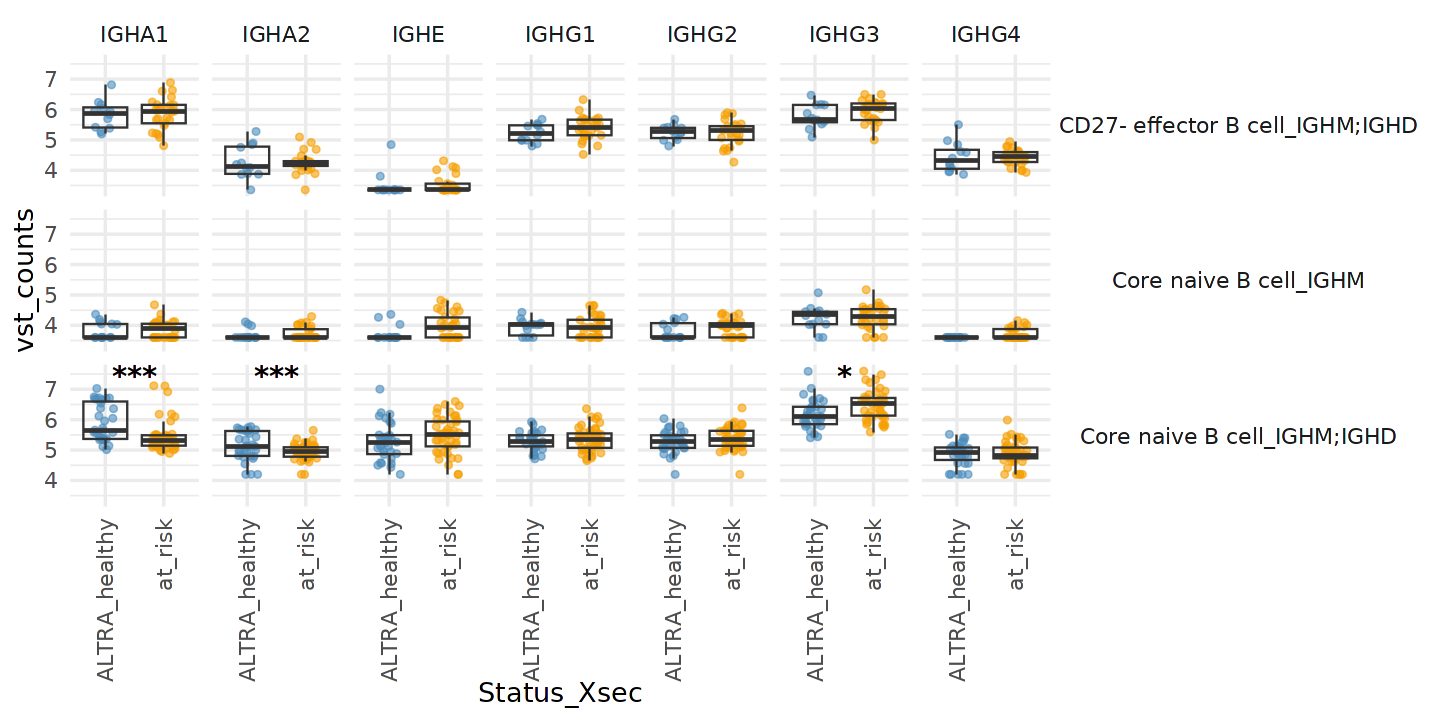

In [77]:
plotdim(12, 6)
df_plot %>%
    ggplot(aes(Status_Xsec, vst_counts)) +
        geom_point(position = position_jitter(height =0, width = 0.2,seed = 3), alpha = 0.6, aes(color = Status_Xsec)) +
        geom_boxplot(alpha = 0) +
        geom_text(x = 1.5, y = Inf, aes(label = signif), check_overlap = TRUE, size = 6, fontface = 'bold', vjust = 1) +
        theme_minimal(base_size = 16) +
        # coord_cartesian(ylim = c(4, 8.5)) +
        facet_grid(celltype_isotype~ gene) +
        scale_color_manual(values = xsec_pal, breaks = names(xsec_pal)) +
        theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1), 
              strip.text.y = element_text(angle = 0),
              # panel.grid = element_blank(), 
              legend.position = 'None') 


In [78]:
# check data limits before setting y-axis range
df_plot %>%
    filter(celltype_isotype == 'Core naive B cell_IGHM;IGHD') %>%
    pull(vst_counts) %>%
    summary()

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  4.199   4.992   5.329   5.421   5.741   7.598 

Don't know how to automatically pick scale for object of type <noquote>.
Defaulting to continuous.


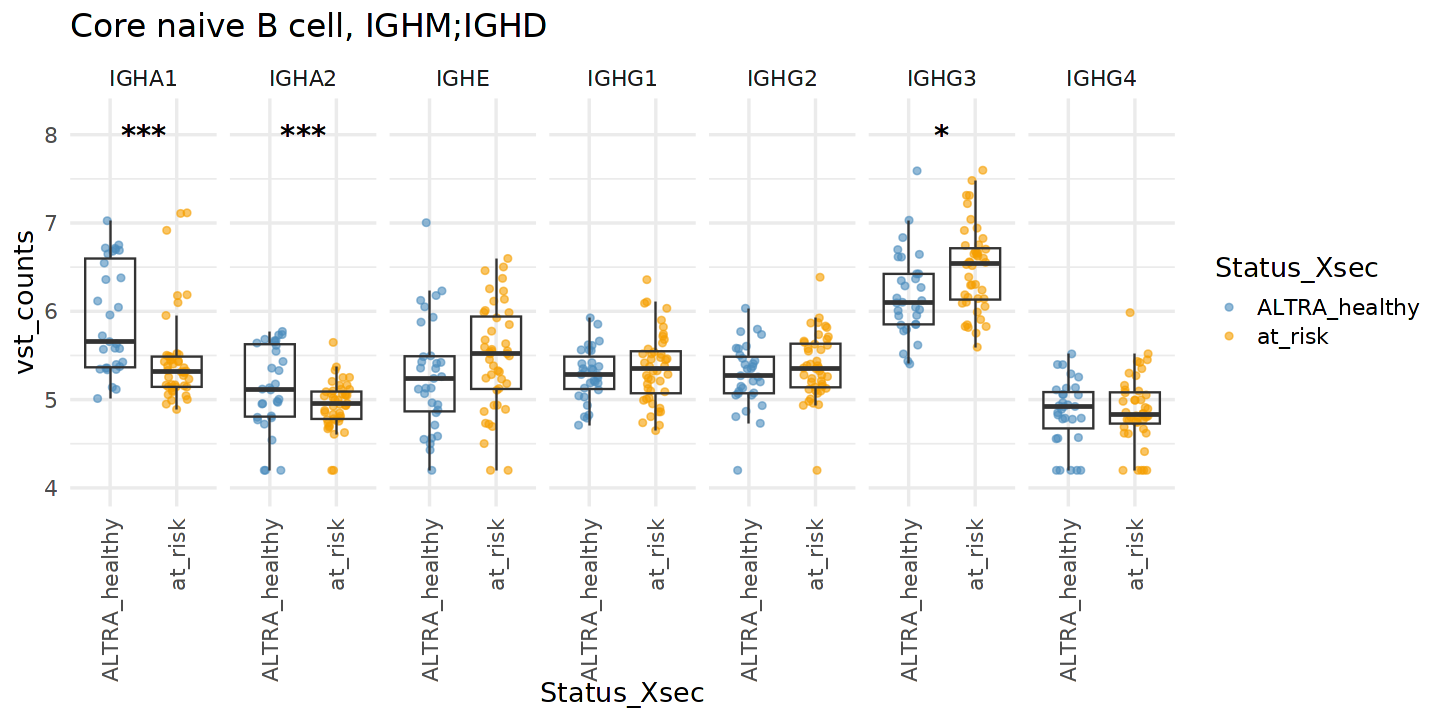

In [78]:
plotdim(12, 6)
df_plot %>%
    filter(celltype_isotype == 'Core naive B cell_IGHM;IGHD') %>%
    ggplot(aes(Status_Xsec, vst_counts)) +
        geom_point(position = position_jitter(height =0, width = 0.2,seed = 3), alpha = 0.6, aes(color = Status_Xsec)) +
        geom_boxplot(alpha = 0) +
        geom_text(x = 1.5, y = 8, aes(label = signif), check_overlap = TRUE, size = 6, fontface = 'bold') +
        theme_minimal(base_size = 16) +
        coord_cartesian(ylim = c(4, 8.2)) +
        facet_grid(~ gene) +
        scale_color_manual(values = xsec_pal, breaks = names(xsec_pal)) +
        theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1), 
              strip.text.y = element_text(angle = 0),
              #legend.position = 'None'
             ) +
    ggtitle('Core naive B cell, IGHM;IGHD')


In [80]:
names(df_plot)

[1] "sample.sampleKitGuid"  "subject.subjectGuid"   "subject.biologicalSex"
 [4] "age"                   "Status_Xsec"           "AIFI_L3_new"          
 [7] "isotype"               "celltype_isotype"      "psbulk_n_cells"       
[10] "psbulk_counts"         "n_umis"                "gene"                 
[13] "raw_pb_counts"         "vst_counts"            "cpm"                  
[16] "log1p_cpm"             "padj_BH_subset"        "log2FoldChange"       
[19] "signif"

Don't know how to automatically pick scale for object of type <noquote>.
Defaulting to continuous.


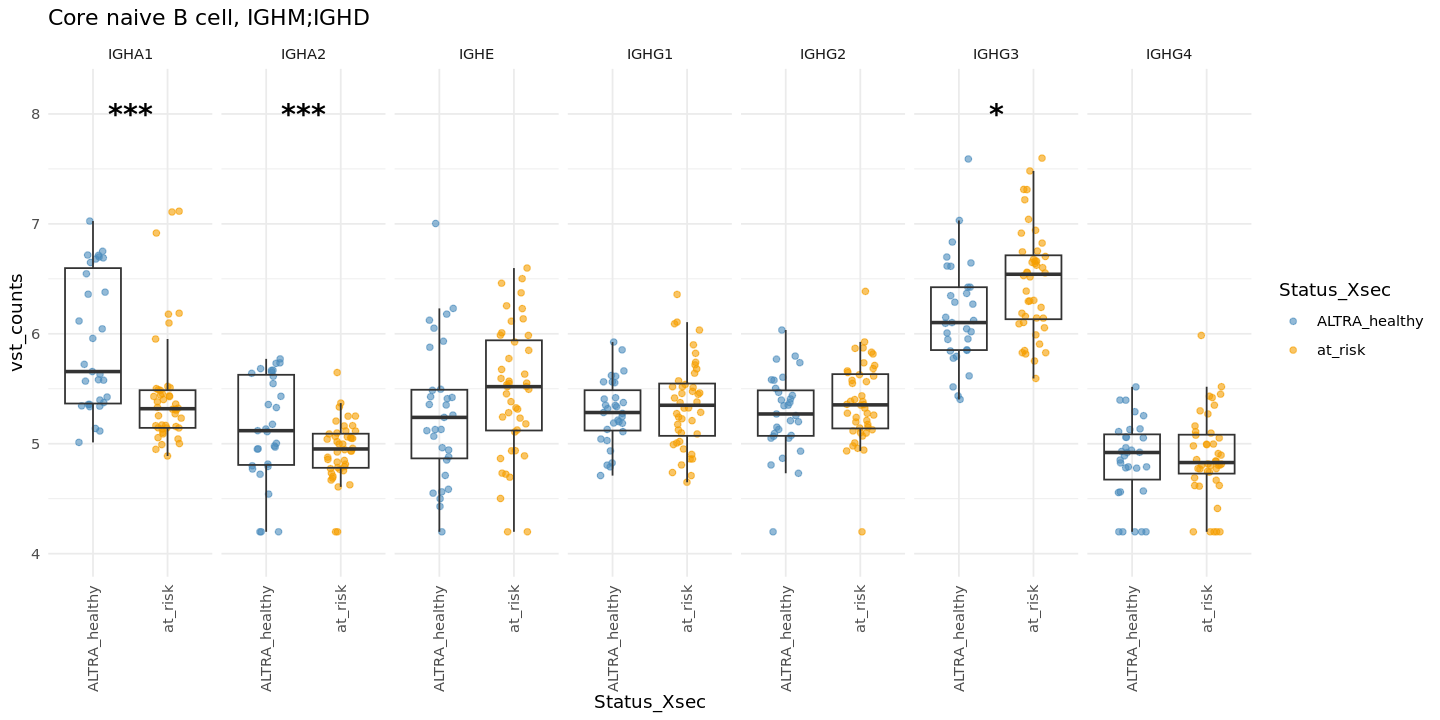

In [85]:
plotdim(12, 6)
g_naive_exp_box <- df_plot %>%
    filter(celltype_isotype == 'Core naive B cell_IGHM;IGHD') %>%
    ggplot(aes(Status_Xsec, vst_counts)) +
        geom_point(position = position_jitter(height =0, width = 0.2,seed = 3), alpha = 0.6, aes(color = Status_Xsec)) +
        geom_boxplot(alpha = 0) +
        geom_text(x = 1.5, y = 8, aes(label = signif), check_overlap = TRUE, size = 6, fontface = 'bold') +
        theme_minimal(base_size = 11) +
        coord_cartesian(ylim = c(4, 8.2)) +
        facet_grid(~ gene) +
        scale_color_manual(values = xsec_pal, breaks = names(xsec_pal)) +
        theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1), 
              strip.text.y = element_text(angle = 0),
              # legend.position = 'None'
             ) +
    ggtitle('Core naive B cell, IGHM;IGHD')
g_naive_exp_box

In [87]:
ggsave("_output/certpro/fig/altra_CoreBNaive-IGMD_pseudobulk-igh-boxplots_cutoff0.5_4by8.pdf", 
       plot = g_naive_exp_box, 
       device = 'pdf', height = 4, width = 8)

Don't know how to automatically pick scale for object of type <noquote>.
Defaulting to continuous.


In [88]:
ggsave("_output/certpro/fig/altra_CoreBNaive-IGMD_pseudobulk-igh-boxplots_cutoff0.5_4by8.png", 
       plot = g_naive_exp_box, 
       device = 'png', height = 4, width = 8, dpi = 600)

Don't know how to automatically pick scale for object of type <noquote>.
Defaulting to continuous.


In [89]:
ggsave("_output/certpro/fig/altra_CoreBNaive-IGMD_pseudobulk-igh-boxplots_cutoff0.5_3by8.pdf", 
       plot = g_naive_exp_box, 
       device = 'pdf', height = 3, width = 8)

Don't know how to automatically pick scale for object of type <noquote>.
Defaulting to continuous.


In [90]:
ggsave("_output/certpro/fig/altra_CoreBNaive-IGMD_pseudobulk-igh-boxplots_cutoff0.5_3by8.png", 
       plot = g_naive_exp_box, 
       device = 'png', height = 3, width = 8, dpi = 600)

Don't know how to automatically pick scale for object of type <noquote>.
Defaulting to continuous.


#### Significant IGH

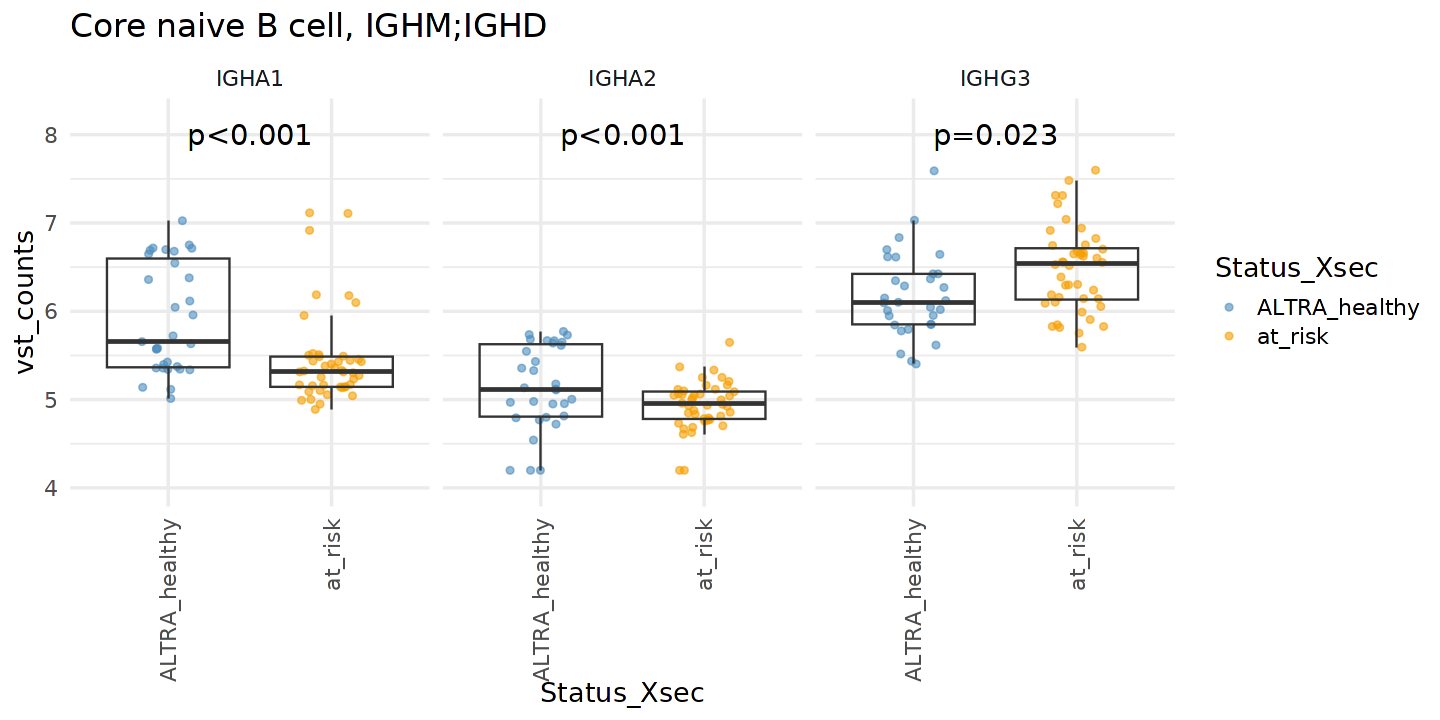

In [125]:
plotdim(12, 6)
df_plot %>%
    filter(celltype_isotype == 'Core naive B cell_IGHM;IGHD') %>%
    mutate(p_label = ifelse(padj_BH_subset< 0.001, "p<0.001", sprintf("p=%.3f",padj_BH_subset))) %>% 
    filter(padj_BH_subset < 0.05) %>%
    ggplot(aes(Status_Xsec, vst_counts)) +
        geom_point(position = position_jitter(height =0, width = 0.2,seed = 3), alpha = 0.6, aes(color = Status_Xsec)) +
        geom_boxplot(alpha = 0) +
        geom_text(x = 1.5, y = 8, aes(label = p_label), check_overlap = TRUE, size = 6) +
        theme_minimal(base_size = 16) +
        coord_cartesian(ylim = c(4, 8.2)) +
        facet_grid(~ gene) +
        scale_color_manual(values = xsec_pal, breaks = names(xsec_pal)) +
        theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1), 
              strip.text.y = element_text(angle = 0),
              #legend.position = 'None'
             ) +
    ggtitle('Core naive B cell, IGHM;IGHD')


In [128]:
plotdim(12, 6)
g_naive_exp_box <- df_plot %>%
    filter(celltype_isotype == 'Core naive B cell_IGHM;IGHD') %>%
    mutate(p_label = ifelse(padj_BH_subset< 0.001, "p<0.001", sprintf("p=%.3f",padj_BH_subset))) %>% 
    filter(padj_BH_subset < 0.05) %>%
    ggplot(aes(Status_Xsec, vst_counts)) +
        geom_point(position = position_jitter(height =0, width = 0.2,seed = 3), alpha = 0.6, aes(color = Status_Xsec)) +
        geom_boxplot(alpha = 0) +
        geom_text(x = 1.5, y = 8, aes(label = p_label), check_overlap = TRUE, size = 3) +
        theme_minimal(base_size = 11) +
        coord_cartesian(ylim = c(4, 8.2)) +
        facet_wrap(~ gene, scales = 'free') +
        scale_color_manual(values = xsec_pal, breaks = names(xsec_pal)) +
        theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1), 
              strip.text.y = element_text(angle = 0),
              #legend.position = 'None'
             ) +
    ggtitle('Core naive B cell, IGHM;IGHD')


In [129]:
ggsave("_output/certpro/fig/altra_CoreBNaive-IGMD_pseudobulk-igh-boxplots_cutoff0.5_signifonly_3by6.pdf", 
       plot = g_naive_exp_box, 
       device = 'pdf', height = 3, width = 6)

Save plot table

In [107]:
write.csv(df_plot, "./_output/certpro/isotype_differentials/targetpop_diff-switched-IGH_plot-table.csv")

### All Populations

In [108]:
length(se_list_test)

[1] 11

In [109]:
length(res_list_target)

[1] 3

In [110]:
keep_pop

[1] CD27+ effector B cell_IGHM;IGHD CD27- effector B cell_IGHM;IGHD
 [3] Core memory B cell_IGHA1        Core memory B cell_IGHG1       
 [5] Core memory B cell_IGHG3        Core memory B cell_IGHM        
 [7] Core memory B cell_IGHM;IGHD    Core naive B cell_IGHM         
 [9] Core naive B cell_IGHM;IGHD     ISG+ naive B cell_IGHM;IGHD    
[11] Transitional B cell_IGHM;IGHD  
31 Levels: CD27+ effector B cell_IGHM ... Type 2 polarized memory B cell_IGHM

In [111]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,8951744,478.1,15016901,802.0,15016901,802
Vcells,293379155,2238.4,482659203,3682.4,436327909,3329


In [112]:
keep_pop

[1] CD27+ effector B cell_IGHM;IGHD CD27- effector B cell_IGHM;IGHD
 [3] Core memory B cell_IGHA1        Core memory B cell_IGHG1       
 [5] Core memory B cell_IGHG3        Core memory B cell_IGHM        
 [7] Core memory B cell_IGHM;IGHD    Core naive B cell_IGHM         
 [9] Core naive B cell_IGHM;IGHD     ISG+ naive B cell_IGHM;IGHD    
[11] Transitional B cell_IGHM;IGHD  
31 Levels: CD27+ effector B cell_IGHM ... Type 2 polarized memory B cell_IGHM

In [114]:
se_list_normcounts_all <- list()
for (ct in keep_pop){
    message(ct)
    se_list_normcounts_all[[ct]] = addNormcounts(se_list_test[[ct]], res_list_all[[ct]], 'vst')
    
}

CD27+ effector B cell_IGHM;IGHD

CD27- effector B cell_IGHM;IGHD

Core memory B cell_IGHA1

Core memory B cell_IGHG1

Core memory B cell_IGHG3

Core memory B cell_IGHM

Core memory B cell_IGHM;IGHD

Core naive B cell_IGHM

Core naive B cell_IGHM;IGHD

ISG+ naive B cell_IGHM;IGHD

Transitional B cell_IGHM;IGHD



In [115]:
df_all <- list()
for (ct in keep_pop){
    print(ct)
    x1 <- se_list_test[[ct]]
    x2 <- se_list_normcounts_all[[ct]]
    meta = colData(x1) %>%
        as.data.frame() %>%
        select(sample.sampleKitGuid, subject.subjectGuid, subject.biologicalSex, age, Status_Xsec, AIFI_L3_new, isotype, celltype_isotype, psbulk_n_cells,psbulk_counts)
    meta$n_umis = colSums(SummarizedExperiment::assay(x1,'X'))
    df = data.frame(t(SummarizedExperiment::assay(x1,'X')))
    df_norm <- data.frame(t(SummarizedExperiment::assay(x2,'normalized_counts')))
    df_norm <- df_norm[,switched_genes]
    res1 <- cbind(meta, df[,switched_genes]) %>%
        gather(key = 'gene', value ='raw_pb_counts', all_of(switched_genes))
    res2 <- cbind(meta, df_norm[,switched_genes]) %>%
        gather(key = 'gene', value ='vst_counts', all_of(switched_genes))
    df_all[[ct]] <- res1 %>%
        left_join(res2) %>%
        mutate(cpm = raw_pb_counts/n_umis*10^6) %>%
        mutate(log1p_cpm = log1p(cpm))
    
}
df_all<- df_all %>%
    bind_rows() 

[1] "CD27+ effector B cell_IGHM;IGHD"


Joining with `by = join_by(sample.sampleKitGuid, subject.subjectGuid,
subject.biologicalSex, age, Status_Xsec, AIFI_L3_new, isotype,
celltype_isotype, psbulk_n_cells, psbulk_counts, n_umis, gene)`


[1] "CD27- effector B cell_IGHM;IGHD"


Joining with `by = join_by(sample.sampleKitGuid, subject.subjectGuid,
subject.biologicalSex, age, Status_Xsec, AIFI_L3_new, isotype,
celltype_isotype, psbulk_n_cells, psbulk_counts, n_umis, gene)`


[1] "Core memory B cell_IGHA1"


...

Joining with `by = join_by(sample.sampleKitGuid, subject.subjectGuid,
subject.biologicalSex, age, Status_Xsec, AIFI_L3_new, isotype,
celltype_isotype, psbulk_n_cells, psbulk_counts, n_umis, gene)`


[1] "ISG+ naive B cell_IGHM;IGHD"


Joining with `by = join_by(sample.sampleKitGuid, subject.subjectGuid,
subject.biologicalSex, age, Status_Xsec, AIFI_L3_new, isotype,
celltype_isotype, psbulk_n_cells, psbulk_counts, n_umis, gene)`


[1] "Transitional B cell_IGHM;IGHD"


Joining with `by = join_by(sample.sampleKitGuid, subject.subjectGuid,
subject.biologicalSex, age, Status_Xsec, AIFI_L3_new, isotype,
celltype_isotype, psbulk_n_cells, psbulk_counts, n_umis, gene)`


In [116]:
head(df_all, 2)

,sample.sampleKitGuid,subject.subjectGuid,subject.biologicalSex,age,Status_Xsec,AIFI_L3_new,isotype,celltype_isotype,psbulk_n_cells,psbulk_counts,n_umis,gene,raw_pb_counts,vst_counts,cpm,log1p_cpm
,<fct>,<chr>,<fct>,<int>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,KT00056,CU1007,Female,42,at_risk,CD27+ effector B cell,IGHM;IGHD,CD27+ effector B cell_IGHM;IGHD,28,260579,260579,IGHG3,24,5.625590,92.10259,4.533702
2,KT00057,CU1003,Female,21,at_risk,CD27+ effector B cell,IGHM;IGHD,CD27+ effector B cell_IGHM;IGHD,56,440478,440478,IGHG3,26,5.295315,59.02678,4.094791


In [117]:
res_df_all_fmt <- res_all_df %>%
    mutate(isotype = gsub(".*_","", celltype_isotype)) %>%    
    mutate(AIFI_L3_new = gsub("_.*","", celltype_isotype)) %>%
    select(celltype_isotype, AIFI_L3_new, isotype, features, padj_BH_subset, log2FoldChange) %>%
    dplyr::rename(gene = features) 
df_all_plot <- df_all %>%
    left_join(res_df_all_fmt) %>%
    mutate(signif = symnum(padj_BH_subset, corr = FALSE, na = FALSE, cutpoints = c(0, 0.001, 0.01, 0.05, 0.1, 1), symbols = c("***", "**", "*", ".", " ")))

Joining with `by = join_by(AIFI_L3_new, isotype, celltype_isotype, gene)`


In [118]:
head(df_all_plot, 2)

,sample.sampleKitGuid,subject.subjectGuid,subject.biologicalSex,age,Status_Xsec,AIFI_L3_new,isotype,celltype_isotype,psbulk_n_cells,psbulk_counts,n_umis,gene,raw_pb_counts,vst_counts,cpm,log1p_cpm,padj_BH_subset,log2FoldChange,signif
,<fct>,<chr>,<fct>,<int>,<fct>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<noquote>
1,KT00056,CU1007,Female,42,at_risk,CD27+ effector B cell,IGHM;IGHD,CD27+ effector B cell_IGHM;IGHD,28,260579,260579,IGHG3,24,5.625590,92.10259,4.533702,0.8715931,0.1014378,
2,KT00057,CU1003,Female,21,at_risk,CD27+ effector B cell,IGHM;IGHD,CD27+ effector B cell_IGHM;IGHD,56,440478,440478,IGHG3,26,5.295315,59.02678,4.094791,0.8715931,0.1014378,


In [120]:
unique(df_all_plot$celltype_isotype)

[1] "CD27+ effector B cell_IGHM;IGHD" "CD27- effector B cell_IGHM;IGHD"
 [3] "Core memory B cell_IGHA1"        "Core memory B cell_IGHG1"       
 [5] "Core memory B cell_IGHG3"        "Core memory B cell_IGHM"        
 [7] "Core memory B cell_IGHM;IGHD"    "Core naive B cell_IGHM"         
 [9] "Core naive B cell_IGHM;IGHD"     "ISG+ naive B cell_IGHM;IGHD"    
[11] "Transitional B cell_IGHM;IGHD"

Save plot table

In [121]:
write.csv(df_all_plot, "./_output/certpro/isotype_differentials/allpop_diff-switched-IGH_plot-table.csv")

## Sample Count Barplots

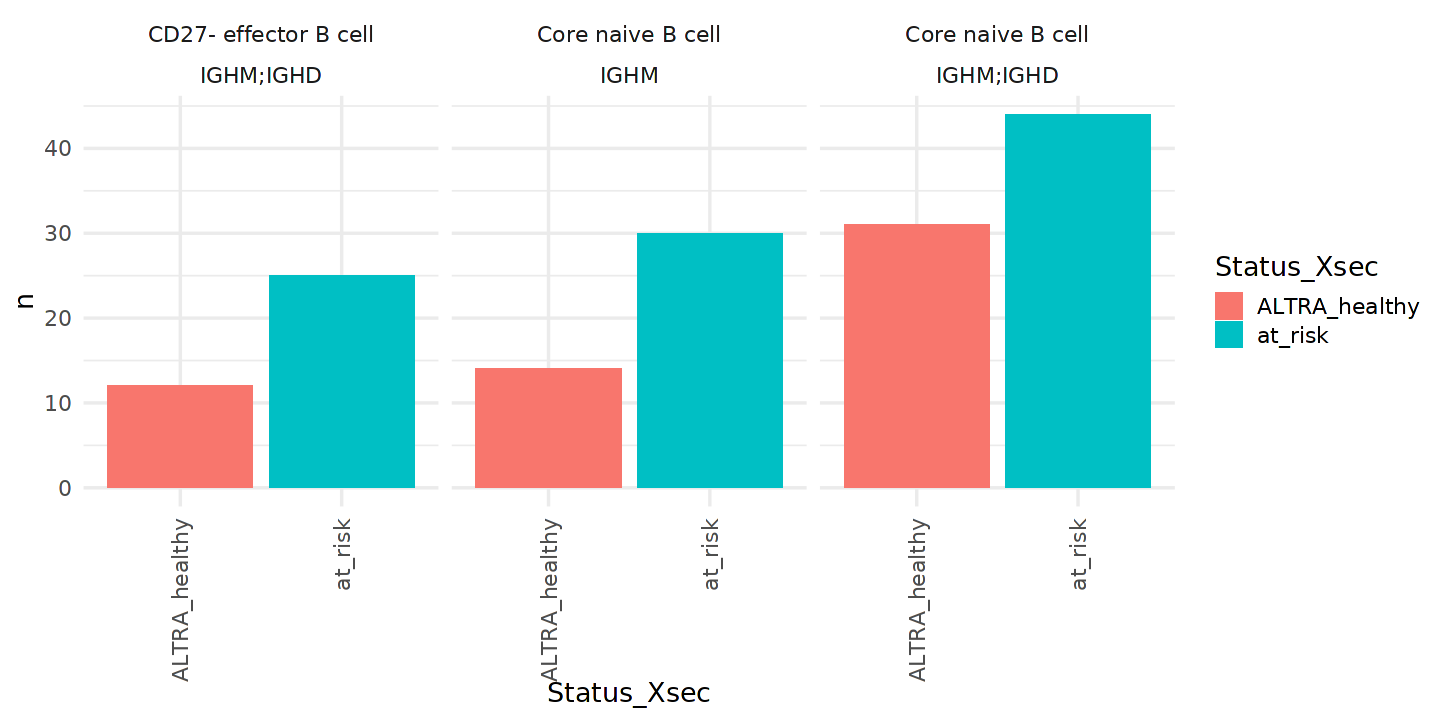

In [122]:
plotdim(12, 6)

df_plot %>%
    select(sample.sampleKitGuid, AIFI_L3_new, isotype, celltype_isotype, Status_Xsec) %>%
    distinct() %>%
    group_by(AIFI_L3_new, isotype, celltype_isotype, Status_Xsec) %>%
    tally() %>%
    ggplot(aes(Status_Xsec, n, fill = Status_Xsec)) +
        geom_col() +
        facet_wrap(AIFI_L3_new~isotype) +
        theme_minimal(base_size = 16) +
        theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1))

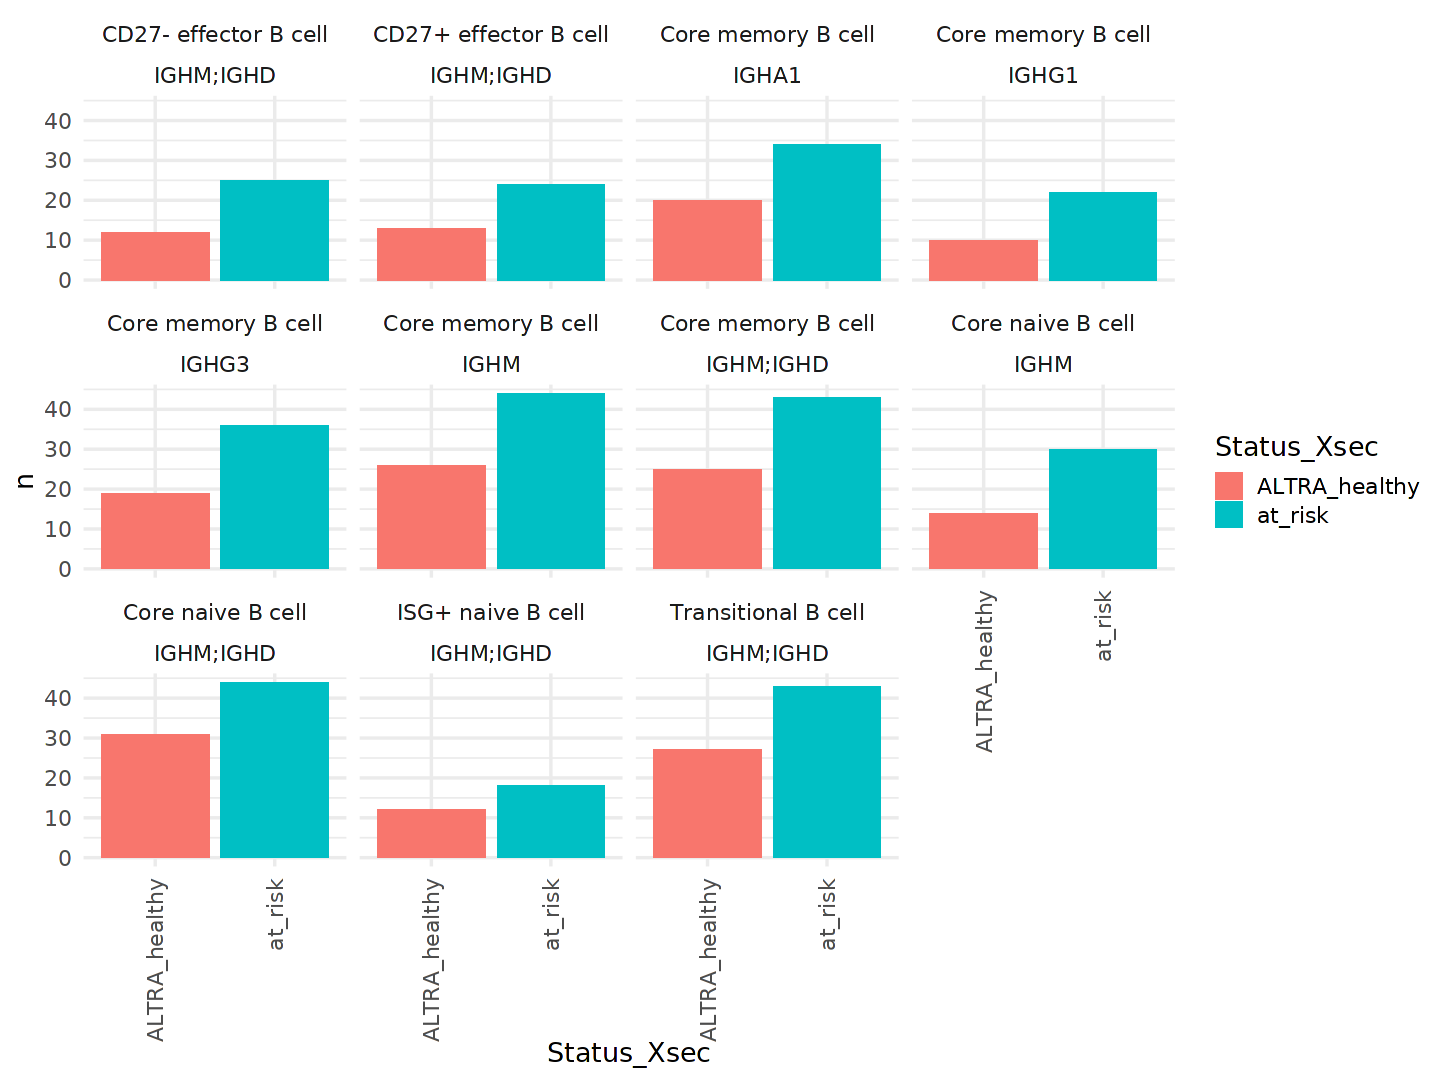

In [123]:
plotdim(12, 9)

df_all_plot %>%
    select(sample.sampleKitGuid, AIFI_L3_new, isotype, celltype_isotype, Status_Xsec) %>%
    distinct() %>%
    group_by(AIFI_L3_new, isotype, celltype_isotype, Status_Xsec) %>%
    tally() %>%
    ggplot(aes(Status_Xsec, n, fill = Status_Xsec)) +
        geom_col() +
        facet_wrap(AIFI_L3_new~isotype) +
        theme_minimal(base_size = 16) +
        theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1))

## Session Info

In [124]:
sessionInfo()

R version 4.2.2 Patched (2022-11-10 r83330)
Platform: x86_64-pc-linux-gnu (64-bit)
Running under: Ubuntu 20.04.5 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/liblapack.so.3

locale:
 [1] LC_CTYPE=C.UTF-8       LC_NUMERIC=C           LC_TIME=C.UTF-8       
 [4] LC_COLLATE=C.UTF-8     LC_MONETARY=C.UTF-8    LC_MESSAGES=C.UTF-8   
 [7] LC_PAPER=C.UTF-8       LC_NAME=C              LC_ADDRESS=C          
[10] LC_TELEPHONE=C         LC_MEASUREMENT=C.UTF-8 LC_IDENTIFICATION=C   

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] BiocParallel_1.32.5         DESeq2_1.38.3              
 [3] SummarizedExperiment_1.28.0 Biobase_2.58.0             
 [5] GenomicRanges_1.50.2        GenomeInfoDb_1.34.9        
 [7] zellkonverter_1.8.0         HDF5Array_1.26.0           
 [9] rhdf5_2.42.0                Delaye